### 1

In [31]:
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
dataset_path = 'dataset/Base.csv'
data = pd.read_csv(dataset_path)

# Undersampling

In [33]:
fraud = data[data['fraud_bool'] == 1]
legal = data[data['fraud_bool'] == 0]
legal_downsampled = resample(legal, replace=False, n_samples=len(fraud), random_state=42)
balanced_data = pd.concat([fraud, legal_downsampled])

# Encoding

In [34]:
le = LabelEncoder()
cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
for col in cat_cols:
    balanced_data[col] = le.fit_transform(balanced_data[col])

## Separazione feature e target

In [35]:
# Assicuriamoci che y sia definita
y = balanced_data['fraud_bool']

# Selezioniamo le 4 feature più significative
# Selezioniamo le 4 feature
# Usiamo le feature con la correlazione più alta
selected_features = ['credit_risk_score', 'proposed_credit_limit', 'device_fraud_count', 'income']
X_selected = balanced_data[selected_features]

# Correzione dello scaling
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_final = scaler.fit_transform(X_selected)

print(f"Dataset pronto. Feature: {selected_features}")

Dataset pronto. Feature: ['credit_risk_score', 'proposed_credit_limit', 'device_fraud_count', 'income']


### 2

/tmp/ipykernel_14159/2445491619.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='full')


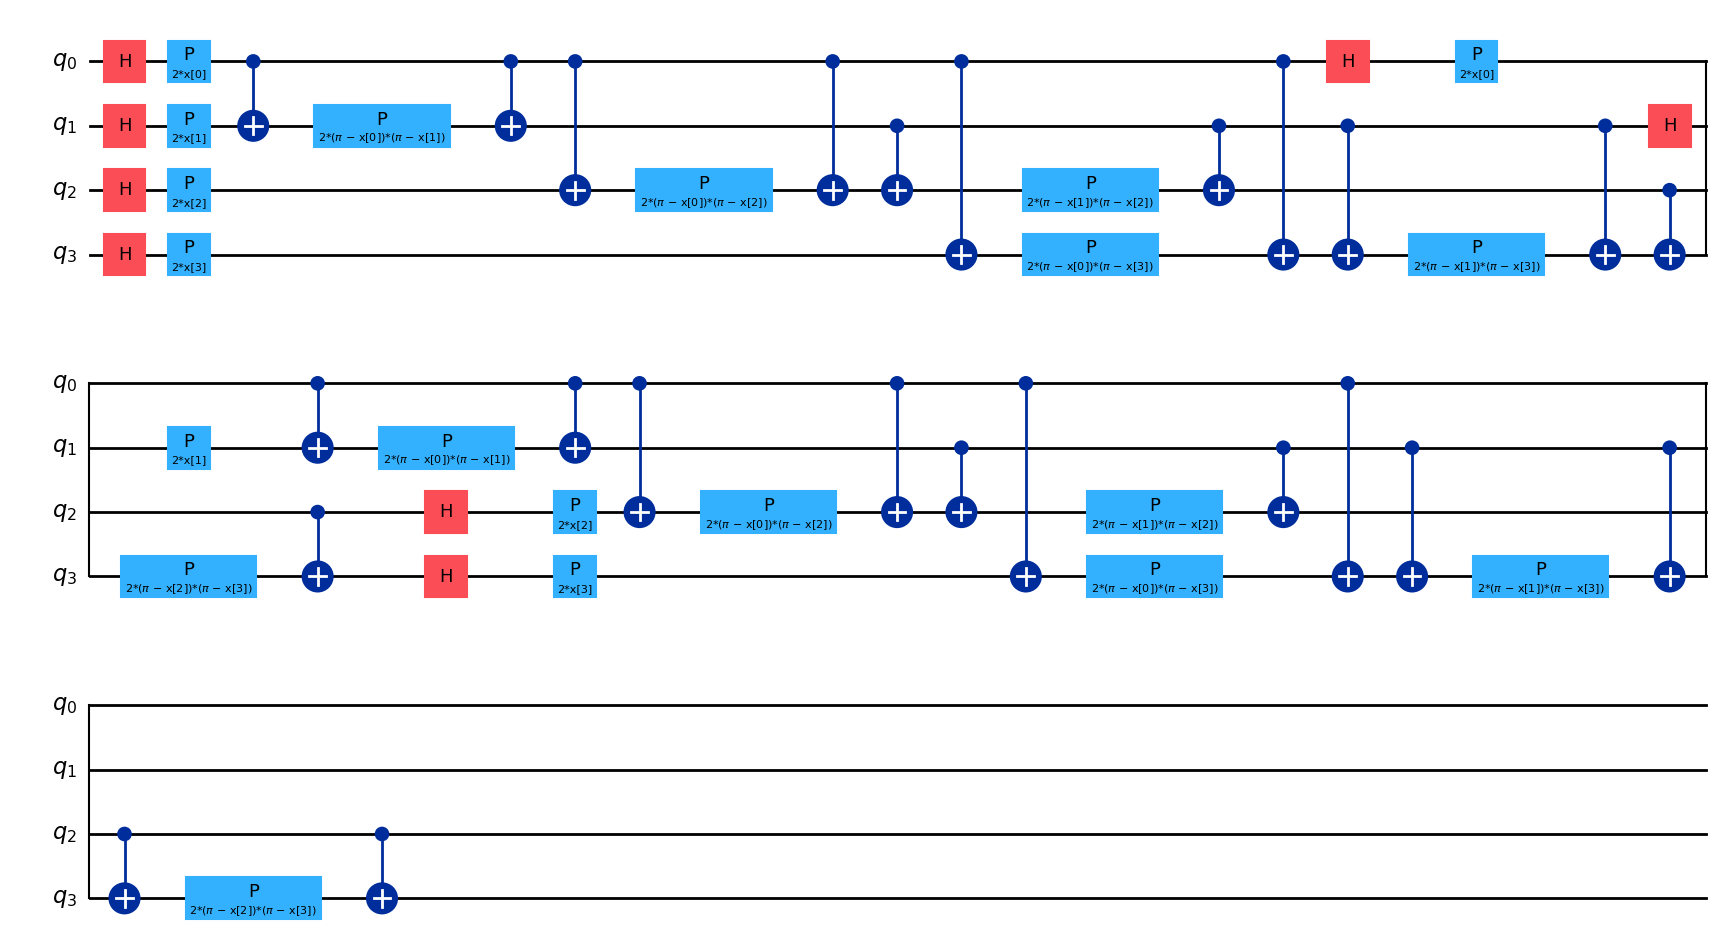

In [36]:
from qiskit.circuit.library import ZZFeatureMap

num_qubits = 4
# reps = 2 indica quante volte ripetere il pattern di encoding (maggiore profondità = più complessità catturata)
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='full')

# Visualizziamo il circuito per capire come vengono mappati i dati
feature_map.decompose().draw(output='mpl')

### 3

# Split dataset

In [37]:
from sklearn.model_selection import train_test_split

# 1. Split normale
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Creazione sottoinsieme di training VELOCE (1000 campioni bilanciati) | Prova anche 2000
X_train, _, y_train, _ = train_test_split(
    X_train_full, y_train_full, train_size=2000, stratify=y_train_full, random_state=42
)

print(f"Training set ridotto a: {len(X_train)} campioni")
print(f"Test set (per la verifica finale): {len(X_test)} campioni")


Training set ridotto a: 2000 campioni
Test set (per la verifica finale): 4412 campioni


# Creazione ansatz

/tmp/ipykernel_14159/4162043423.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=num_qubits, reps=5, entanglement='linear')


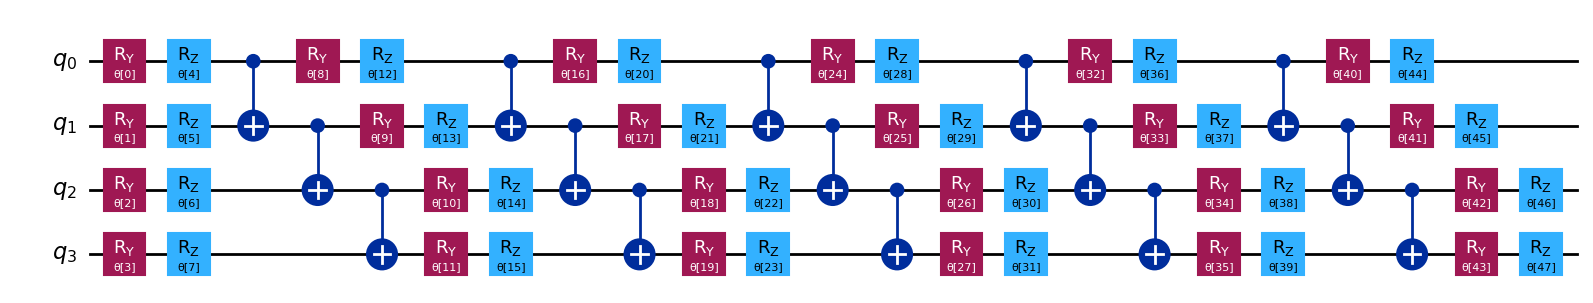

In [38]:
from qiskit.circuit.library import EfficientSU2

num_qubits = 4
# Aumentiamo reps a 5 per dare più "espressività"
ansatz = EfficientSU2(num_qubits=num_qubits, reps=5, entanglement='linear')

ansatz.decompose().draw(output='mpl')

# Setup VQC

In [39]:
from qiskit_algorithms.optimizers import SPSA
from qiskit_machine_learning.algorithms import VQC
from qiskit.primitives import StatevectorSampler

import matplotlib.pyplot as plt # <--- AGGIUNGI QUESTA RIGA
from IPython.display import clear_output

# SPSA fa meno valutazioni del circuito ed è più veloce con molti dati
objective_func_vals = []

# Usiamo *args per accettare qualsiasi numero di argomenti
def callback_graph(*args):
    # Estrai il valore della loss in base all'ottimizzatore
    if len(args) == 5:
        iteration = len(objective_func_vals) + 1
        obj_val = args[2]
    else:
        iteration = len(objective_func_vals) + 1
        obj_val = args[1]
    
    objective_func_vals.append(obj_val)
    clear_output(wait=True)
    print(f"Iterazione {iteration}: Loss = {obj_val:.4f}")
    
    # Ora 'plt' funzionerà correttamente
    plt.figure(figsize=(10, 5))
    plt.title("Andamento del Training (SPSA)")
    plt.plot(objective_func_vals, label="Loss")
    plt.xlabel("Iterazione")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

optimizer = SPSA(maxiter=250) # Prova anche 200+

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    sampler=StatevectorSampler(),
    callback=callback_graph
)

print("VQC aggiornato con SPSA e 5 layer!")


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


VQC aggiornato con SPSA e 5 layer!


### 4

# Training

Iterazione 250: Loss = 0.9402


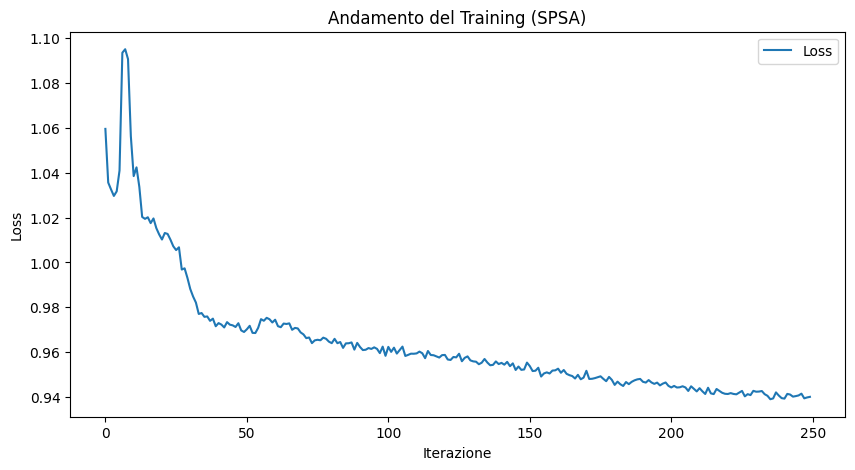

Training completato in 5201.83 secondi


In [40]:
# Se vuoi fare un test veloce, scommenta la riga sotto:
# X_train_small, y_train_small = X_train[:100], y_train[:100]

start_time = time.time()
vqc.fit(X_train, y_train.values) # .values per passare un array numpy
end_time = time.time()

print(f"Training completato in {end_time - start_time:.2f} secondi")


# Valutazioni


--- Risultati del Modello ---
              precision    recall  f1-score   support

      Legale       0.58      0.57      0.58      2206
       Frode       0.58      0.58      0.58      2206

    accuracy                           0.58      4412
   macro avg       0.58      0.58      0.58      4412
weighted avg       0.58      0.58      0.58      4412



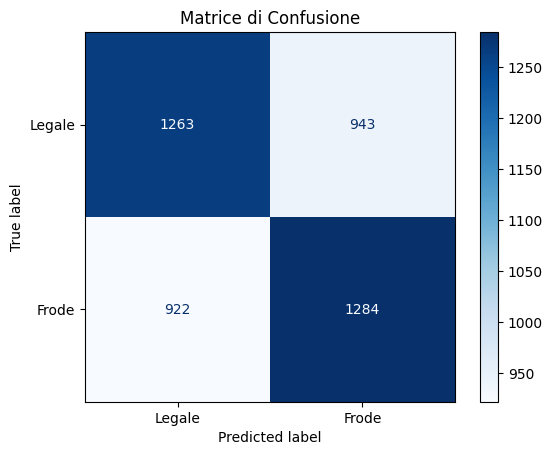

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predizione sul test set
y_pred = vqc.predict(X_test)

# Report completo (Precision, Recall, F1)
print("\n--- Risultati del Modello ---")
print(classification_report(y_test, y_pred, target_names=['Legale', 'Frode']))

# Visualizzazione Matrice di Confusione
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legale', 'Frode'])
disp.plot(cmap='Blues')
plt.title("Matrice di Confusione")
plt.show()
